# Arab 813 Hackathon - Data exploration with open access satellite datasets

## 🌍 Earth Observation Hackathon Notebook

Welcome! This notebook will help you explore satellite data for the Arab 813 Hackathon.

---

## What you will learn

- What satellite data is
- What STAC is and why it's important
- How to access satellite imagery without downloading files
- How to calculate simple indices like:
  - NDVI (vegetation health)
  - NDWI (water detection)

---

## What is satellite data?

Satellites continuously capture images of Earth. These images contain scientific information about:
- Vegetation (crops, forests)
- Water bodies
- Urban areas
- Temperature and climate

---

## What is STAC?

STAC = **SpatioTemporal Asset Catalog**

Think of STAC as:
👉 A **search engine for satellite data**

Instead of downloading data manually, STAC allows you to:
- Search by location (bounding box)
- Filter by time
- Select datasets quickly
- Access data directly from the cloud

---

## What are COGs?

COG = **Cloud Optimized GeoTIFF**

This means:

✅ You can read only the part of the image you need  
✅ No need to download entire files  
✅ Faster and scalable  

---

Let's get started 🚀

In [54]:
%pip install pystac-client planetary-computer stackstac rasterio xarray matplotlib geopandas leafmap ipywidgets rioxarray

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [55]:
%pip install --upgrade certifi requests==2.32.4 urllib3 leafmap

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [56]:
# Impor libraries

import pystac_client
import planetary_computer
import stackstac
import matplotlib.pyplot as plt
import numpy as np

import rioxarray
import leafmap
from IPython.display import display

In [57]:
# Titiler endpoint

import os

os.environ["TITILER_ENDPOINT"] = "planetary-computer"
#titiler_endpoint="pc"
titiler_endpoint="planetary-computer"


## Step 1 – Define Area of Interest (AOI)

We need to tell the system **where on Earth to look**.

We define a bounding box:
[min longitude, min latitude, max longitude, max latitude]

We also define a time rnage

This example uses a region in the UAE.

In [58]:
bbox = [54.0, 24.0, 55.0, 25.0]  # [min lon, min lat, max lon, max lat]
time_range = "2025-01-01/2025-03-01"

# 1. Initialize map
m = leafmap.Map(center=[24.5, 54.5], zoom=8)

# 2. Add the bounding box as a layer
# layer_name allows you to toggle it on/off in the layer control
m.add_bbox(bbox, layer_name="AOI Bounding Box", color="red", fill_opacity=0.1)

# 3. Optional: Zoom the map directly to the extent of your bbox
m.zoom_to_bounds(bbox)

m

Map(center=[24.5, 54.5], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out…

## Step 2 - Connect to Sentinel-2 STAC


We connect to the **Planetary Computer STAC API**, which hosts Sentinel‑2 data.

Sentinel‑2 is a satellite that provides:
- Multispectral imagery
- High resolution (10–20m)
- Useful for agriculture, water, and urban analysis


In [59]:
import pystac_client
import planetary_computer

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1"
)

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)


## Step 3 - Search for satellite imagery

We search for images using:
- Bounding box (AOI)
- Date range
- Cloud cover filter

This avoids downloading unnecessary data.


In [60]:
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    #datetime="2025-01-01/2025-03-01",
    datetime = time_range,
    query={"eo:cloud_cover": {"lt": 20}}, # we can set a cloud cover % treshold to filter out cloudy images
)

items = list(search.get_items())
len(items)

70

### Inspecting the retrieved list of STAC images

Using a GeoDataFrame is the standard professional approach for Earth Observation workflows. It allows you to:

- Visualize Coverage: You can plot the footprints of all available satellite scenes to see which ones overlap your area of interest.

- Filter Metadata: You can easily sort by eo:cloud_cover, datetime, or mgrs:utm_zone using standard Pandas filtering:

In [61]:
import pystac
import geopandas

# 1. Convert the list of items into an ItemCollection
item_collection = pystac.ItemCollection(items)

# 2. Now convert the ItemCollection to a GeoDataFrame
# This method extracts the geometry and properties automatically
df = geopandas.GeoDataFrame.from_features(
    item_collection.to_dict(), 
    crs="epsg:4326"
)

# Preview the results
print(df.head())

                                            geometry  \
0  POLYGON ((54.92275 25.30152, 54.91902 25.28754...   
1  POLYGON ((54.41689 23.64506, 54.2398 23.69331,...   
2  POLYGON ((54.91283 25.26431, 54.87966 25.13976...   
3  POLYGON ((52.98622 25.30335, 54.07586 25.28464...   
4  POLYGON ((54.41689 23.64506, 54.2398 23.69331,...   

                      datetime     platform  proj:epsg instruments  \
0  2025-03-01T06:57:29.024000Z  Sentinel-2B      32640       [msi]   
1  2025-03-01T06:57:29.024000Z  Sentinel-2B      32640       [msi]   
2  2025-03-01T06:57:29.024000Z  Sentinel-2B      32639       [msi]   
3  2025-03-01T06:57:29.024000Z  Sentinel-2B      32639       [msi]   
4  2025-03-01T06:57:29.024000Z  Sentinel-2B      32639       [msi]   

  s2:mgrs_tile constellation  \
0        40RBN    Sentinel 2   
1        40QBM    Sentinel 2   
2        39RZH    Sentinel 2   
3        39RYH    Sentinel 2   
4        39QZG    Sentinel 2   

                                       s2:granule


## Step 4 – Load Data from the Cloud

We now load imagery directly from cloud-hosted COGs.

We select bands:
- B04 → Red
- B03 → Green
- B02 → Blue

Together, these form an RGB image.
``


In [62]:

data = stackstac.stack(
    items,
    assets=["B04", "B03", "B02"],
    resolution=10,
    bounds_latlon=bbox,
    epsg=4326
).median(dim="time")


## Step 5 – Visualize Sentinel-2 RGB Image

We display the satellite image as a normal photo.
``

In [63]:
#%conda install -c conda-forge localtileserver
import pip
%pip install localtileserver
import localtileserver

item = items[0]
url = item.assets["visual"].href
print(url)

#m.add_raster(url, name="Sentinel-2 RGB")
m.add_cog_layer(url, name="Sentinel-2 RGB", titiler_endpoint="titiler_endpoint")
m

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/40/R/BN/2025/03/01/S2B_MSIL2A_20250301T065729_N0511_R063_T40RBN_20250301T091446.SAFE/GRANULE/L2A_T40RBN_A041702_20250301T070158/IMG_DATA/R10m/T40RBN_20250301T065729_TCI_10m.tif
Invalid URL 'titiler_endpoint/cog/info': No scheme supplied. Perhaps you meant https://titiler_endpoint/cog/info?


Map(center=[24.5, 54.5], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out…

In [64]:
import leafmap
import pystac_client
import planetary_computer

# 1. Initialize map centered over the UAE area
bbox = [54.0, 24.0, 55.0, 25.0]  # [min lon, min lat, max lon, max lat]
m = leafmap.Map(center=[24.5, 54.5], zoom=8)

# 2. Query the STAC API catalog
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1"
)

search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime="2025-01-01/2025-03-01",
    query={"eo:cloud_cover": {"lt": 20}},
)

items = list(search.get_items())
first_item = items[0]

# 3. Add the layer using leafmap's native STAC interpreter with the "pc" shortcode
m.add_stac_layer(
    collection="sentinel-2-l2a",
    item=first_item.id,
    assets=["visual"],       # Serves pre-compiled RGB. Use ["B04", "B03", "B02"] for raw bands
    titiler_endpoint="pc",   # Tells leafmap to route requests through Planetary Computer's tiler smoothly
    name="Sentinel-2 RGB"
)

m

('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))


Map(center=[24.5, 54.5], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out…

thumbnail = item.assets["thumbnail"].href
print(thumbnail)

## ✅ Next Steps

Now you can:

- Change the AOI to your country or region
- Try different time ranges
- Compare multiple dates (change detection)

---

## 💡 Tips

- Start small (small AOI)
- Avoid downloading large datasets
- Experiment with indices

---

You are now ready to build your hackathon solution 🚀
``

## Planetary computer - Load COGs from STAC dataset  

In [65]:
import leafmap

In [66]:
url = "https://canada-spot-ortho.s3.amazonaws.com/canada_spot_orthoimages/canada_spot5_orthoimages/S5_2007/S5_11055_6057_20070622/S5_11055_6057_20070622.json"

In [67]:
leafmap.stac_assets(url)

{'detail': [{'type': 'missing',
   'loc': ['query', 'collection'],
   'msg': 'Field required',
   'input': None},
  {'type': 'missing',
   'loc': ['query', 'item'],
   'msg': 'Field required',
   'input': None}]}

In [68]:
leafmap.stac_bounds(url)

In [69]:
collection = "landsat-8-c2-l2"

In [70]:
# import os
os.environ["TITILER_ENDPOINT"] = "planetary-computer"

In [71]:
item = "LC08_L2SP_047027_20201204_02_T1"

In [72]:
import leafmap

# 1. Define your parameters correctly
collection_id = "landsat-c2-l2" # Correct collection for the ID you provided
item_id = "LC08_L2SP_047027_20201204_02_T1"

# 2. Add the layer WITHOUT the 'url' argument
m = leafmap.Map()

m.add_stac_layer(
    #collection=collection_id,
    collection = collection,
    item=item,
    # Use the EXACT names from your previous stac_assets() output
    assets=["SR_B4", "SR_B3", "SR_B2"], 
    name="Landsat 8 RGB",
    titiler_endpoint="pc" 
)

m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [73]:
m = leafmap.Map()
m.add_stac_layer(url, bands=["SR_B3", "SR_B2", "SR_B1"], collection=collection,item = item, name="SPOT5 RGB")
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [74]:
leafmap.stac_assets(collection=collection, item=item, titiler_endpoint="pc")

['SR_B1',
 'SR_B2',
 'SR_B3',
 'SR_B4',
 'SR_B5',
 'SR_B6',
 'SR_B7',
 'ST_QA',
 'ST_B10',
 'ST_DRAD',
 'ST_EMIS',
 'ST_EMSD',
 'ST_TRAD',
 'ST_URAD',
 'QA_PIXEL',
 'ST_ATRAN',
 'ST_CDIST',
 'QA_RADSAT',
 'SR_QA_AEROSOL']

In [75]:
leafmap.stac_bounds(collection=collection, item=item)

[-124.9808633132731, 46.35352340750138, -121.78787875260963, 48.52103509752985]

In [76]:
leafmap.stac_info(collection=collection, item=item, assets="SR_B7")

{'SR_B7': {'bounds': [-124.9808633132731,
   46.35352340750138,
   -121.78787875260963,
   48.52103509752985],
  'minzoom': 7,
  'maxzoom': 12,
  'band_metadata': [['b1', {}]],
  'band_descriptions': [['b1', '']],
  'dtype': 'uint16',
  'nodata_type': 'Nodata',
  'colorinterp': ['gray'],
  'scales': [1.0],
  'offsets': [0.0],
  'driver': 'GTiff',
  'count': 1,
  'width': 7861,
  'height': 7971,
  'overviews': [2, 4, 8, 16, 32, 64],
  'nodata_value': 0.0}}

In [77]:
leafmap.stac_stats(collection=collection, item=item, assets="SR_B7")

{'SR_B7_b1': {'min': 6912.0,
  'max': 32069.0,
  'mean': 8275.555009181073,
  'count': 673124.0,
  'sum': 5570474690.0,
  'std': 1156.664685686523,
  'median': 8046.0,
  'majority': 7295.0,
  'minority': 6912.0,
  'unique': 8681.0,
  'histogram': [[587083.0,
    79039.0,
    4498.0,
    1328.0,
    914.0,
    222.0,
    37.0,
    2.0,
    0.0,
    1.0],
   [6912.0,
    9427.7,
    11943.4,
    14459.099999999999,
    16974.8,
    19490.5,
    22006.199999999997,
    24521.899999999998,
    27037.6,
    29553.3,
    32069.0]],
  'valid_percent': 65.08,
  'masked_pixels': 361116.0,
  'valid_pixels': 673124.0,
  'percentile_2': 7278.0,
  'percentile_98': 11233.0}}

### False color composite

In [78]:
m = leafmap.Map()
m.add_stac_layer(
    collection=collection,
    item=item,
    assets=["SR_B5", "SR_B4", "SR_B3"],
    name="Color infrared",
)
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

### Calculate NDVI



NDVI = (NIR - Red) / (NIR + Red)

This tells us how healthy vegetation is:
- Green → healthy vegetation
- Yellow → moderate
- Brown/red → dry or no vegetation

In [79]:
m = leafmap.Map()
m.add_stac_layer(
    collection=collection,
    item=item,
    expression="(SR_B5-SR_B4)/(SR_B5+SR_B4)",
    rescale="-1,1",
    name="NDVI",
)
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

### Plot NDVI using a green pseudo color

In [80]:
m = leafmap.Map()
m.add_stac_layer(
    collection=collection, item=item, assets="SR_B5,SR_B4,SR_B3", name="Color infrared"
)
m.add_stac_layer(
    collection=collection,
    item=item,
    expression="(SR_B5-SR_B4)/(SR_B5+SR_B4)",
    rescale="-1,1",
    colormap_name="greens",
    name="NDVI Green",
)
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

## Planet STAC collection

In [81]:
tanager_url = "https://www.planet.com/data/stac/browser/tanager-core-imagery/coastal-water-bodies/collection.json"

# 🌊 Planet Tanager Coastal Water Bodies Explorer

This notebook helps you explore **Planet’s Tanager hyperspectral dataset**.

---

## What You Will Learn

- What hyperspectral satellite data is
- How to query a STAC catalog
- How to explore metadata
- How to visualize quicklook images
- How to derive simple insights (time, location, coverage)

---

## What is Tanager?

Tanager is a **hyperspectral satellite mission** providing:
- High spectral resolution (many bands)
- Detailed water and coastal analysis capability

Unlike Sentinel‑2:
- It captures many more spectral bands
- It enables detailed chemical/biophysical analysis

We connect to Planet’s open STAC collection.

---

## What is STAC?

STAC (SpatioTemporal Asset Catalog) lets you:
- Search satellite data
- Access metadata
- Retrieve imagery

👉 Think: “Google for satellite data”


## Step 1 – Connect to the STAC Collection


In [82]:
import requests

# Example subset (you can expand this list)
item_ids = [
    "20250223_165546_32_4001",
    "20250225_153627_16_4001",
    "20250302_030003_92_4001",
    "20250311_061550_53_4001",
    "20250406_170447_47_4001"
]

items = []

for iid in item_ids:
    url = f"https://www.planet.com/data/stac/tanager-core-imagery/coastal-water-bodies/{iid}/{iid}.json"
    items.append(requests.get(url).json())

print(f"Loaded {len(items)} scenes")

Loaded 5 scenes


## Step 2 – Inspect Metadata

In [83]:
item = items[0]

print("ID:", item["id"])
print("Date:", item["properties"]["datetime"])
print("Bounding Box:", item["bbox"])

ID: 20250223_165546_32_4001
Date: 2025-02-23T16:55:46.321891Z
Bounding Box: [-88.56425877863482, 13.139414553891845, -88.34746243694369, 13.316052417927148]


## Step 3 – View Full Metadata

Each image includes detailed metadata.

In [84]:
import json

print(json.dumps(item["properties"], indent=2))

{
  "cloud_percent": 0,
  "collection_mode": "standard_sensitivity",
  "constellation": "Tanager",
  "datetime": "2025-02-23T16:55:46.321891Z",
  "description": "All data products from Tanager-1 for 20250223_165546_32_4001 near Usulut\u00e1n, 3401, El Salvador",
  "gsd": 32.85,
  "instruments": [
    "4001"
  ],
  "license": "CC-BY-4.0",
  "light_haze_percent": 0,
  "location_description": "Usulut\u00e1n, 3401, El Salvador",
  "notes": null,
  "platform": "Planet",
  "plume_provider_ids": null,
  "quality_category": "standard",
  "title": "TanagerScene 20250223_165546_32_4001 Core Imagery",
  "view:azimuth": 263.4,
  "view:off_nadir": 11.2,
  "view:sun_azimuth": 141.3,
  "view:sun_elevation": 61.2
}


## Step 4 – Display Image

Quicklook images allow fast visualization.


In [85]:
from IPython.display import Image

thumbnail = item["assets"]["thumbnail"]["href"]
Image(url=thumbnail)

## Step 5 – Display Full Resolution Image (COG)

Instead of using the thumbnail, we load the actual **Cloud Optimized GeoTIFF (COG)**.

COGs allow:
- Partial loading from cloud
- Efficient visualization
- Real satellite data access

We will display the `analytic` or `visual` asset.
``

In [86]:
import leafmap
from IPython.display import display

# Create map (we'll zoom to the scene after loading)
m = leafmap.Map(center=[24.2, 55.7], zoom=7)

# Pick the real COG GeoTIFF visual asset
asset_key = "ortho_visual"
cog_url = item["assets"][asset_key]["href"]

print("Using asset:", asset_key)
print("COG URL:", cog_url)

# Zoom to item bbox (recommended so you actually see it)
bbox = item["bbox"]  # [minx, miny, maxx, maxy]
m.fit_bounds([[bbox[1], bbox[0]], [bbox[3], bbox[2]]])

# Preferred method for COGs (fast + good rendering)
if hasattr(m, "add_cog_layer"):
    #m.add_cog_layer(cog_url, name=f"Tanager {asset_key}"),
    m.add_cog_layer(cog_url, name=f"Tanager {asset_key}", titiler_endpoint="https://titiler.xyz"),
    titiler_endpoint="pc"  # leafmap's default public titiler
else:
    # fallback for older leafmap versions
    m.add_raster(cog_url, layer_name=f"Tanager {asset_key}")

display(m)

Using asset: ortho_visual
COG URL: https://storage.googleapis.com/open-cogs/planet-stac/tanager1-release2-core-imagery/ortho_visual/20250223_165546_32_4001_ortho_visual.tif


Map(center=[-88.45589371743637, 13.227770535956875], controls=(ZoomControl(options=['position', 'zoom_in_text'…

## Step 6 – Geographical Coverage

### Let's plot the image bounding box so we get a good underestanding of the image extent

In [87]:
import geopandas as gpd
from shapely.geometry import box

bbox = item["bbox"]
geom = box(*bbox)

gdf = gpd.GeoDataFrame({"geometry": [geom]}, crs="EPSG:4326")

m.add_gdf(gdf, layer_name="Scene Footprint", style={"color": "red", "fillOpacity": 0})
m

Map(center=[13.227770535956875, -88.45589371743637], controls=(ZoomControl(options=['position', 'zoom_in_text'…

### Compute spatial analytics from Tanager hdf5 file

- For ocean/coastal monitoring, hyperspectral indices usually rely on specific wavelengths, and Tanager’s true spectral data is typically in: 
basic_sr_hdf5 or ortho_sr_hdf5 (surface reflectance, 0–1)

In [88]:
sr_key = "ortho_sr_hdf5" if "ortho_sr_hdf5" in item["assets"] else "basic_sr_hdf5"
sr_url = item["assets"][sr_key]["href"]
print("Using SR HDF5:", sr_key)
print(sr_url)

Using SR HDF5: ortho_sr_hdf5
https://storage.googleapis.com/open-cogs/planet-stac/tanager1-release2-core-imagery/ortho_sr_hdf5/20250223_165546_32_4001_ortho_sr_hdf5.h5


In [89]:
%pip install -U h5py

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


### Analytics optiona A: Stream hyperspectral data directly from the notebook

In [90]:
import h5py, requests, io

# Download into memory (small scenes ok). If large, download to disk with streaming.
data = requests.get(sr_url).content
f = h5py.File(io.BytesIO(data), "r")

# Inspect available groups/datasets
def walk_h5(name, obj):
    if isinstance(obj, h5py.Dataset):
        print("DATASET:", name, obj.shape, obj.dtype)
    elif isinstance(obj, h5py.Group):
        pass

f.visititems(walk_h5)

DATASET: HDFEOS/GRIDS/HYP/Data Fields/aerosol_optical_depth (655, 785) float32
DATASET: HDFEOS/GRIDS/HYP/Data Fields/beta_cirrus_mask (655, 785) uint8
DATASET: HDFEOS/GRIDS/HYP/Data Fields/beta_cloud_mask (655, 785) uint8
DATASET: HDFEOS/GRIDS/HYP/Data Fields/column_water_vapour (655, 785) float32
DATASET: HDFEOS/GRIDS/HYP/Data Fields/nodata_pixels (655, 785) uint8
DATASET: HDFEOS/GRIDS/HYP/Data Fields/sensor_azimuth (655, 785) float32
DATASET: HDFEOS/GRIDS/HYP/Data Fields/sensor_to_ground_path_length (655, 785) float32
DATASET: HDFEOS/GRIDS/HYP/Data Fields/sensor_zenith (655, 785) float32
DATASET: HDFEOS/GRIDS/HYP/Data Fields/sun_azimuth (655, 785) float32
DATASET: HDFEOS/GRIDS/HYP/Data Fields/sun_zenith (655, 785) float32
DATASET: HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance (426, 655, 785) float32
DATASET: HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance_uncertainty (426, 655, 785) float32
DATASET: HDFEOS/GRIDS/HYP/Data Fields/time (655, 785) float64
DATASET: HDFEOS INFORMATION/

### Download HDF5 image once and then compute statistics

### 1) Download the HDF5 file locally 
##### (May take some time and is dependent on your internet speed... so get a coffee)

In [91]:
import os
import requests

# Pick the surface reflectance HDF5 asset from the STAC item
sr_key = "ortho_sr_hdf5" if "ortho_sr_hdf5" in item["assets"] else "basic_sr_hdf5"
sr_url = item["assets"][sr_key]["href"]

print("Using SR asset:", sr_key)
print("Download URL:", sr_url)

# Save locally using the filename from the URL
local_path = os.path.basename(sr_url)

if not os.path.exists(local_path):
    print("Downloading file...")
    with requests.get(sr_url, stream=True) as r:
        r.raise_for_status()
        with open(local_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):  # 1 MB chunks
                if chunk:
                    f.write(chunk)
    print("Saved to:", local_path)
else:
    print("File already exists:", local_path)

Using SR asset: ortho_sr_hdf5
Download URL: https://storage.googleapis.com/open-cogs/planet-stac/tanager1-release2-core-imagery/ortho_sr_hdf5/20250223_165546_32_4001_ortho_sr_hdf5.h5
File already exists: 20250223_165546_32_4001_ortho_sr_hdf5.h5


### 2) Read masks and compute quick scene-quality statistics


In [92]:
import h5py
import numpy as np

root = "HDFEOS/GRIDS/HYP/Data Fields"

with h5py.File(local_path, "r") as f:
    cloud = f[f"{root}/beta_cloud_mask"][:]      # (655, 785)
    nodata = f[f"{root}/nodata_pixels"][:]       # (655, 785)
    cirrus = f[f"{root}/beta_cirrus_mask"][:]    # (655, 785)

valid = (nodata == 0) & (cloud == 0) & (cirrus == 0)

valid_pct = valid.mean() * 100
cloud_pct = (cloud != 0).mean() * 100
cirrus_pct = (cirrus != 0).mean() * 100
nodata_pct = (nodata != 0).mean() * 100

print(f"Valid pixels:  {valid_pct:.1f}%")
print(f"Cloud pixels:  {cloud_pct:.1f}%")
print(f"Cirrus pixels: {cirrus_pct:.1f}%")
print(f"NoData pixels: {nodata_pct:.1f}%")

Valid pixels:  72.2%
Cloud pixels:  0.0%
Cirrus pixels: 0.0%
NoData pixels: 27.8%


### 3) Extract band wavelengths from the STAC metadata
This is a very useful trick: the STAC item asset metadata often already contains the spectral band center wavelengths, so you don’t need to guess.


In [93]:
# Extract spectral wavelengths from the STAC asset metadata
#bands_meta = item["assets"][sr_key].get("eo:bands", [])
bands_meta = item["assets"][sr_key].get("bands", [])
#bands_meta = item["assets"][sr_key].get("raster:bands", [])

# Keep only true spectral bands (ignore mask/geometry metadata entries)
#spectral_bands = [b for b in bands_meta if "center_wavelength" in b]
spectral_bands = [b for b in bands_meta if "eo:center_wavelength" in b]

#wavelengths_um = np.array([b["center_wavelength"] for b in spectral_bands], dtype=float)
wavelengths_um = np.array([b["eo:center_wavelength"] for b in spectral_bands], dtype=float)
wavelengths_nm = wavelengths_um * 1000.0  # convert micrometers -> nanometers

print("Number of spectral bands from STAC:", len(wavelengths_nm))
print("First 10 wavelengths (nm):", np.round(wavelengths_nm[:10], 2))
print("Last 10 wavelengths (nm):", np.round(wavelengths_nm[-10:], 2))

Number of spectral bands from STAC: 426
First 10 wavelengths (nm): [376.44 381.41 386.38 391.35 396.32 401.29 406.26 411.23 416.21 421.18]
Last 10 wavelengths (nm): [2454.39 2459.35 2464.31 2469.26 2474.22 2479.18 2484.13 2489.09 2494.04
 2499.  ]


### Check consistency
The hyperspectral cube you found is:

surface_reflectance (426, 655, 785)

So we should verify the wavelength vector length matches the band dimension:

In [94]:
with h5py.File(local_path, "r") as f:
    sr_shape = f[f"{root}/surface_reflectance"].shape

print("Surface reflectance cube shape:", sr_shape)

if sr_shape[0] != len(wavelengths_nm):
    print("⚠️ Warning: band count and wavelength count differ.")
else:
    print("✅ Wavelength count matches cube band dimension.")

Surface reflectance cube shape: (426, 655, 785)
✅ Wavelength count matches cube band dimension.


### 4) Helper functions for band selection
We’ll choose the band nearest to a target wavelength in nanometers.

In [95]:
def nearest_band_idx(wavelengths_nm, target_nm):
    return int(np.argmin(np.abs(wavelengths_nm - target_nm)))

def print_band_choice(target_nm, wavelengths_nm):
    idx = nearest_band_idx(wavelengths_nm, target_nm)
    actual = wavelengths_nm[idx]
    print(f"Target {target_nm:.0f} nm -> band {idx} ({actual:.2f} nm)")
    return idx

### 5) Pick useful wavelengths for marine/coastal monitoring
These are practical choices:

- NDVI → coastal vegetation / mangroves

    - Red ≈ 665 nm
    - NIR ≈ 800 nm


- NDWI → water detection

    - Green ≈ 560 nm
    - NIR ≈ 860 nm


- NDCI → chlorophyll / algae bloom proxy

    - Red ≈ 665 nm
    - Red-edge ≈ 708 nm


- Turbidity proxy (NDTI style)

    - Red ≈ 665 nm
    - Green ≈ 560 nm

In [96]:
b560 = print_band_choice(560, wavelengths_nm)
b665 = print_band_choice(665, wavelengths_nm)
b708 = print_band_choice(708, wavelengths_nm)
b800 = print_band_choice(800, wavelengths_nm)
b860 = print_band_choice(860, wavelengths_nm)

Target 560 nm -> band 37 (560.83 nm)
Target 665 nm -> band 58 (665.87 nm)
Target 708 nm -> band 66 (705.92 nm)
Target 800 nm -> band 85 (801.12 nm)
Target 860 nm -> band 97 (861.26 nm)


### 6) Load only the few required bands (fast)
This is the key speed trick:
👉 we do not read the full 426-band cube, only the bands needed for the indices.

In [97]:
with h5py.File(local_path, "r") as f:
    sr = f[f"{root}/surface_reflectance"]

    R560 = sr[b560, :, :].astype("float32")
    R665 = sr[b665, :, :].astype("float32")
    R708 = sr[b708, :, :].astype("float32")
    R800 = sr[b800, :, :].astype("float32")
    R860 = sr[b860, :, :].astype("float32")

Apply the valid mask:

R560[~valid] = np.nan
R665[~valid] = np.nan
R708[~valid] = np.nan
R800[~valid] = np.nan
R860[~valid] = np.nan

### 7) Compute indices
#### *NDVI - Near Difference Vegetation Index*

Useful for:

- mangroves
- coastal vegetation
- wetland vegetation

Good for:

- mangrove condition
- saltmarsh / coastal vegetation health
- distinguishing vegetation from bare/wet surfaces

In [98]:
NDVI = (R800 - R665) / (R800 + R665 + 1e-6)

#### NDWI - Near Difference Water Index
Useful for:
- water detection
- distinguishing water from vegetation/soil

In [99]:
NDWI = (R560 - R860) / (R560 + R860 + 1e-6)

#### NDCI - Near Difference Chlorophyll Index
Useful for:

- chlorophyll proxy
- potential algal blooms / phytoplankton activity

In [100]:
NDCI = (R708 - R665) / (R708 + R665 + 1e-6)

#### Turbidity proxy (NDTI style)
- A simple proxy for suspended material / turbidity:

In [101]:
Turbidity = (R665 - R560) / (R665 + R560 + 1e-6)

### 8) Plot the indices

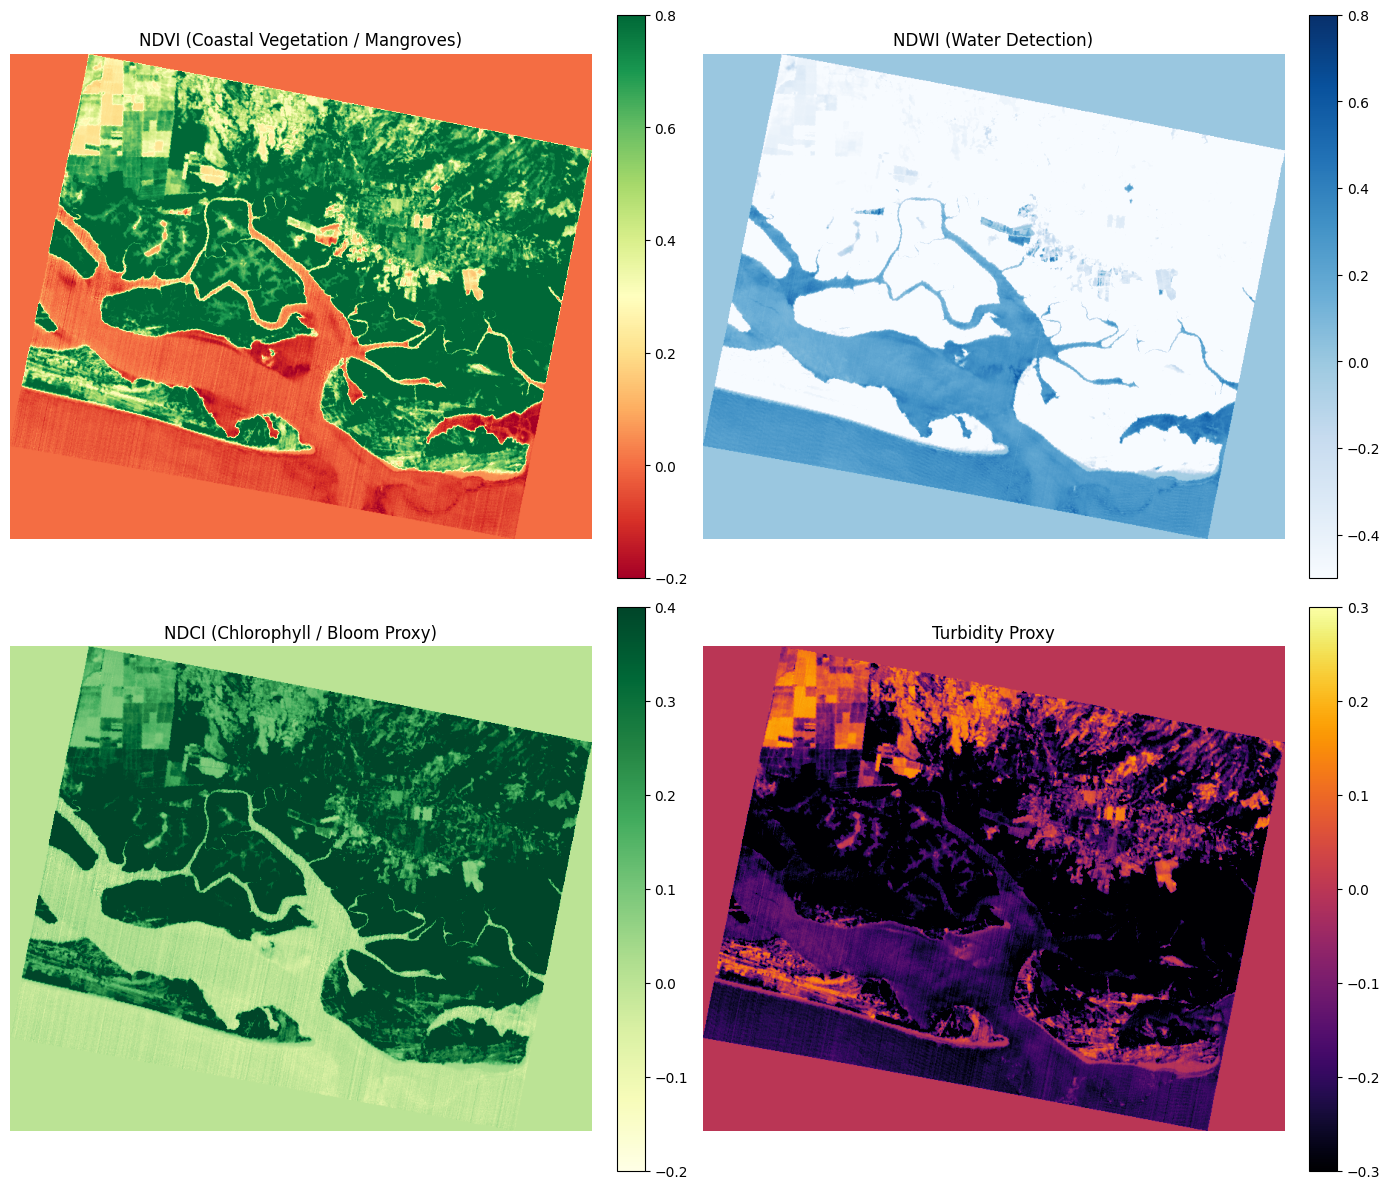

In [102]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

im1 = axes[0,0].imshow(NDVI, cmap="RdYlGn", vmin=-0.2, vmax=0.8)
axes[0,0].set_title("NDVI (Coastal Vegetation / Mangroves)")
axes[0,0].axis("off")
plt.colorbar(im1, ax=axes[0,0], fraction=0.046, pad=0.04)

im2 = axes[0,1].imshow(NDWI, cmap="Blues", vmin=-0.5, vmax=0.8)
axes[0,1].set_title("NDWI (Water Detection)")
axes[0,1].axis("off")
plt.colorbar(im2, ax=axes[0,1], fraction=0.046, pad=0.04)

im3 = axes[1,0].imshow(NDCI, cmap="YlGn", vmin=-0.2, vmax=0.4)
axes[1,0].set_title("NDCI (Chlorophyll / Bloom Proxy)")
axes[1,0].axis("off")
plt.colorbar(im3, ax=axes[1,0], fraction=0.046, pad=0.04)

im4 = axes[1,1].imshow(Turbidity, cmap="inferno", vmin=-0.3, vmax=0.3)
axes[1,1].set_title("Turbidity Proxy")
axes[1,1].axis("off")
plt.colorbar(im4, ax=axes[1,1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### 9) Print quick summary statistics


In [103]:
def summarize_index(name, arr):
    print(f"{name}:")
    print(f"  min   = {np.nanmin(arr):.4f}")
    print(f"  max   = {np.nanmax(arr):.4f}")
    print(f"  mean  = {np.nanmean(arr):.4f}")
    print(f"  std   = {np.nanstd(arr):.4f}")
    print()

summarize_index("NDVI", NDVI)
summarize_index("NDWI", NDWI)
summarize_index("NDCI", NDCI)
summarize_index("Turbidity", Turbidity)

NDVI:
  min   = -0.3335
  max   = 0.9783
  mean  = 0.3584
  std   = 0.3846

NDWI:
  min   = -0.8466
  max   = 0.6319
  mean  = -0.2697
  std   = 0.3915

NDCI:
  min   = -0.1763
  max   = 0.8737
  mean  = 0.2194
  std   = 0.2422

Turbidity:
  min   = -0.8459
  max   = 0.2227
  mean  = -0.1660
  std   = 0.1730



### 10 Mean spectrum for valid pixels
This gives a very useful scene-level “spectral fingerprint”

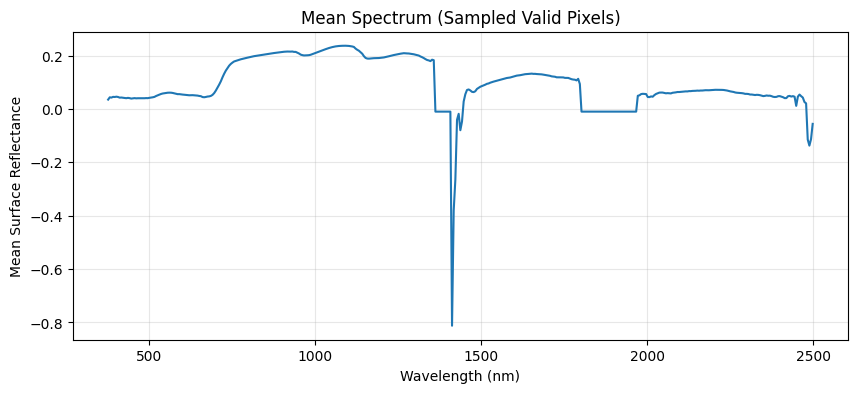

In [104]:
stride = 8  # increase for faster speed, decrease for more detail

with h5py.File(local_path, "r") as f:
    sr = f[f"{root}/surface_reflectance"]

    # spatial sampling
    cube_sample = sr[:, ::stride, ::stride].astype("float32")  # (bands, y, x)
    mask_sample = valid[::stride, ::stride]

    cube_sample[:, ~mask_sample] = np.nan
    mean_spectrum = np.nanmean(cube_sample, axis=(1, 2))

plt.figure(figsize=(10, 4))
plt.plot(wavelengths_nm, mean_spectrum, lw=1.5)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean Surface Reflectance")
plt.title("Mean Spectrum (Sampled Valid Pixels)")
plt.grid(True, alpha=0.3)
plt.show()

## Water vapor bands
The reason we see negative values and flat lines around 1800 nm is because of water vapor bands.

Why Remove Water Vapor Bands?

Water vapor bands are regions of the spectrum (typically 1350–1450 nm and 1800–1950 nm) where the atmosphere absorbs almost all incoming light.

Why they must be removed:

Atmospheric Noise: Sensors record atmospheric opacity rather than ground reflectance, creating artificial "dips" in your data.

Skewed Statistics: Including these bands introduces heavy noise, which corrupts your mean spectral calculations.

Improved Accuracy: Removing these bands and negative values (artifacts from atmospheric correction) ensures your plot represents the true physical properties of the wetland.

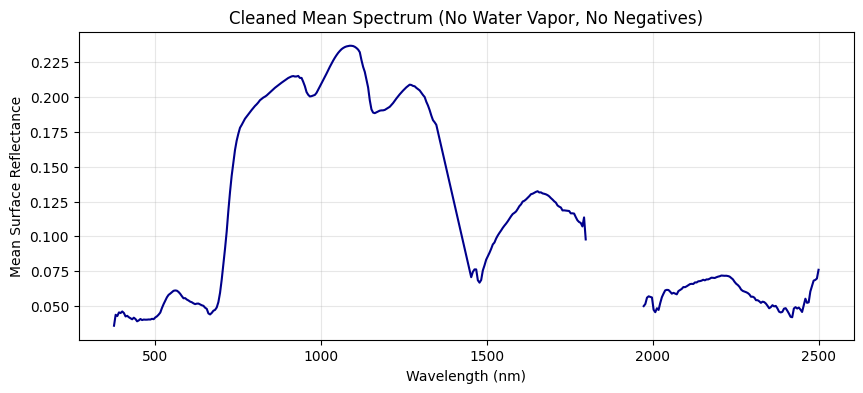

In [105]:
## Let's remove the water vapor bands from the plot.

stride = 8 # increase for faster speed, decrease for more detail.

# Define atmospheric absorption windows to remove (e.g., 1350-1450nm and 1800-1950nm)
# Adjust these based on the specific wavelengths in your HDF5 file
def is_water_vapor_band(wl):
    return (1350 <= wl <= 1450) or (1800 <= wl <= 1950)

with h5py.File(local_path, "r") as f:
    sr = f[f"{root}/surface_reflectance"]

    # 1. Filter out Water Vapor bands by index
    valid_band_indices = [i for i, wl in enumerate(wavelengths_nm) if not is_water_vapor_band(wl)]

    # 2. Spatial sampling and apply band filter
    cube_sample = sr[valid_band_indices, ::stride, ::stride].astype("float32")
    mask_sample = valid[::stride, ::stride]

    # 3. Remove spatial nodata
    cube_sample[:, ~mask_sample] = np.nan

    # 4. REMOVE NEGATIVE VALUES: Set anything < 0 to NaN
    cube_sample[cube_sample < 0] = np.nan

    # Calculate mean ignoring NaNs
    mean_spectrum = np.nanmean(cube_sample, axis=(1, 2))

# Plotting
plt.figure(figsize=(10, 4))
clean_wavelengths = [wavelengths_nm[i] for i in valid_band_indices]

plt.plot(clean_wavelengths, mean_spectrum, lw=1.5, color='darkblue')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean Surface Reflectance")
plt.title("Cleaned Mean Spectrum (No Water Vapor, No Negatives)")
plt.grid(True, alpha=0.3)
plt.show()